# LIBRARIES

In [69]:
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.model_selection import train_test_split

# Loading, converting and cleaning of the data

## MARKET TEMPERATURE DATASET

In [4]:
df_market_temp = pd.read_csv("dataset/Market_temp_index_uc_month.csv")

In [5]:
df_market_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0
1,394913,1,"New York, NY",msa,NY,53.0,52.0,55.0,57.0,56.0,...,92.0,90.0,87.0,81.0,78.0,77.0,77.0,74.0,71.0,71.0
2,753899,2,"Los Angeles, CA",msa,CA,69.0,66.0,66.0,67.0,66.0,...,85.0,83.0,80.0,74.0,71.0,67.0,65.0,63.0,62.0,63.0
3,394463,3,"Chicago, IL",msa,IL,48.0,49.0,51.0,52.0,51.0,...,74.0,76.0,75.0,71.0,67.0,64.0,61.0,58.0,56.0,56.0
4,394514,4,"Dallas, TX",msa,TX,55.0,55.0,58.0,60.0,59.0,...,67.0,67.0,64.0,59.0,55.0,52.0,49.0,48.0,49.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,753929,935,"Zapata, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,39.0,36.0,27.0,40.0,53.0,47.0,31.0,34.0,42.0,41.0
924,394743,936,"Ketchikan, AK",msa,AK,37.0,35.0,34.0,37.0,49.0,...,74.0,69.0,49.0,53.0,61.0,66.0,57.0,53.0,44.0,50.0
925,753874,937,"Craig, CO",msa,CO,3.0,23.0,52.0,67.0,56.0,...,61.0,55.0,59.0,57.0,48.0,33.0,21.0,28.0,41.0,37.0
926,395188,938,"Vernon, TX",msa,TX,51.0,45.0,NaN,48.0,65.0,...,83.0,78.0,64.0,65.0,61.0,52.0,57.0,56.0,51.0,43.0


We can see that market temperature dataset has 928 rows and 88 columns. First 5 columns are:

- ***RegionID:*** Unique identifier. Each US region has an id. 102001 is United States id, not a specific country. There 928 different IDs, except 102001, all other corrispond to a specific region. 
- ***SizeRank:*** Ranking of the region from most populated to the less populated. SizeRank has 925 different values. It means that some of countries have the same rank. They are not NaN values (except United States obviously), I won't "fix" it since it is not a specific region.
- ***RegionName:*** Associates a name to id number. 928 different Region names obviously. 
- ***RegionType:*** 2 different types of regions:
    - **country:** Since we have a row about the United States, here the country is only for US. 
    - **msa:** Metropolitan Statistical Area (all 927 remaining rows).
- ***StateName:*** The name of each state (US of course is NaN)


**Date columns:**<br>
As we can see the other 83 remaining columnns are dates. Pandas sees those dates as a column name (string) not a date sequence. So, I need to transform them to do time series analysis. 

In [6]:
df_market_temp['RegionID'].count()


np.int64(928)

In [7]:
len(df_market_temp['SizeRank'].unique())

925

In [8]:
df_market_temp.isnull().sum()

RegionID       0
SizeRank       0
RegionName     0
RegionType     0
StateName      1
              ..
2024-07-31     1
2024-08-31     5
2024-09-30     7
2024-10-31     8
2024-11-30    13
Length: 88, dtype: int64

In [9]:
len(df_market_temp['RegionName'].unique())

928

In [10]:
df_market_temp['RegionType'].unique()

array(['country', 'msa'], dtype=object)

In [11]:
df_market_temp[df_market_temp['RegionType']=='country']

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0


In [12]:
len(df_market_temp[df_market_temp['RegionType']=='msa'])

927

In [13]:
df_market_temp['StateName'].isnull().sum()

np.int64(1)

### Reshaping the dataset

As we can see the other 83 remaining columnns are dates. Pandas sees those dates as a column name (string) not a date sequence. So, I need to transform them to do time series analysis. 

I use pandas melt function for this operation

In [14]:
df_market_temp

,RegionID,SizeRank,RegionName,RegionType,StateName,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,...,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30
0,102001,0,United States,country,NaN,50.0,50.0,52.0,54.0,55.0,...,63.0,63.0,62.0,59.0,57.0,55.0,53.0,52.0,51.0,50.0
1,394913,1,"New York, NY",msa,NY,53.0,52.0,55.0,57.0,56.0,...,92.0,90.0,87.0,81.0,78.0,77.0,77.0,74.0,71.0,71.0
2,753899,2,"Los Angeles, CA",msa,CA,69.0,66.0,66.0,67.0,66.0,...,85.0,83.0,80.0,74.0,71.0,67.0,65.0,63.0,62.0,63.0
3,394463,3,"Chicago, IL",msa,IL,48.0,49.0,51.0,52.0,51.0,...,74.0,76.0,75.0,71.0,67.0,64.0,61.0,58.0,56.0,56.0
4,394514,4,"Dallas, TX",msa,TX,55.0,55.0,58.0,60.0,59.0,...,67.0,67.0,64.0,59.0,55.0,52.0,49.0,48.0,49.0,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,753929,935,"Zapata, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,39.0,36.0,27.0,40.0,53.0,47.0,31.0,34.0,42.0,41.0
924,394743,936,"Ketchikan, AK",msa,AK,37.0,35.0,34.0,37.0,49.0,...,74.0,69.0,49.0,53.0,61.0,66.0,57.0,53.0,44.0,50.0
925,753874,937,"Craig, CO",msa,CO,3.0,23.0,52.0,67.0,56.0,...,61.0,55.0,59.0,57.0,48.0,33.0,21.0,28.0,41.0,37.0
926,395188,938,"Vernon, TX",msa,TX,51.0,45.0,NaN,48.0,65.0,...,83.0,78.0,64.0,65.0,61.0,52.0,57.0,56.0,51.0,43.0


In [15]:
df_market_temp_updated = df_market_temp.copy()

# pivoting all date columns into rows
df_market_temp_updated = pd.melt(
    df_market_temp,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'], # keep the columns as they are
    var_name='Date',           # the new column that holds dates that were columns
    value_name='MarketTemperature'  # the new column that holds the temperature values, now we have 88 rows for each date and we can see the temperature 
                                    # values here  not like first version that for each region there were 88 columns that holds these temperatures. 
)

# convert columns into pandas timestamp 
df_market_temp_updated['Date'] = pd.to_datetime(df_market_temp_updated['Date'])

# make Date the row index, not just a regular column
df_market_temp_updated.set_index('Date', inplace=True)

In [16]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,NaN,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


In [17]:
df_market_temp_updated.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'MarketTemperature'],
      dtype='object')

In [18]:
df_market_temp_updated.index

DatetimeIndex(['2018-01-31', '2018-01-31', '2018-01-31', '2018-01-31',
               '2018-01-31', '2018-01-31', '2018-01-31', '2018-01-31',
               '2018-01-31', '2018-01-31',
               ...
               '2024-11-30', '2024-11-30', '2024-11-30', '2024-11-30',
               '2024-11-30', '2024-11-30', '2024-11-30', '2024-11-30',
               '2024-11-30', '2024-11-30'],
              dtype='datetime64[ns]', name='Date', length=77024, freq=None)

In [19]:
len(df_market_temp_updated.index.unique())

83

### Market temprature index data cleaning:

- missing values: 
    - in *StateName* there are 83 missing values, but we already know that the United State has a row by its own but don't have anything in StateName, after checking I saw that there is no any region with state name "US" or "us" so instead of deleting United States from the table I will just add "US" as its StateName. 
    - There are other missing values in the *MarketTemperature* column. But, here the problem is not easy as in the StateName. So, I will use ***forward fill - ffill*** method that we saw during the lecture. Since pandas scan each column from top to bottom (earliest date to latest date) the index moves in chronological order and when it hits a NaN, ffill method looks backwards and copies the last known real value. The problem with this method can be the very first value is NaN, in that case I can use ***bfill*** method, which propagates the next known valid value backward to replace missing values.

In [20]:
df_market_temp_updated.isnull().sum()

RegionID                0
SizeRank                0
RegionName              0
RegionType              0
StateName              83
MarketTemperature    2220
dtype: int64

In [21]:
df_market_temp_updated['StateName'].isnull()

Date
2018-01-31     True
2018-01-31    False
2018-01-31    False
2018-01-31    False
2018-01-31    False
              ...  
2024-11-30    False
2024-11-30    False
2024-11-30    False
2024-11-30    False
2024-11-30    False
Name: StateName, Length: 77024, dtype: bool

In [22]:
df_market_temp_updated[
    df_market_temp_updated['StateName'].isna() |
    (df_market_temp_updated['StateName'] == 'NaN')
]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,NaN,50.0
2018-02-28,102001,0,United States,country,NaN,50.0
2018-03-31,102001,0,United States,country,NaN,52.0
2018-04-30,102001,0,United States,country,NaN,54.0
2018-05-31,102001,0,United States,country,NaN,55.0
...,...,...,...,...,...,...
2024-07-31,102001,0,United States,country,NaN,55.0
2024-08-31,102001,0,United States,country,NaN,53.0
2024-09-30,102001,0,United States,country,NaN,52.0


In [23]:
df_market_temp_updated[df_market_temp_updated['StateName']=="us"]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,


In [24]:
df_market_temp_updated['StateName'] = df_market_temp_updated['StateName'].fillna('US')

In [25]:
df_market_temp_updated.isnull().sum()

RegionID                0
SizeRank                0
RegionName              0
RegionType              0
StateName               0
MarketTemperature    2220
dtype: int64

In [26]:
df_market_temp_updated[
    df_market_temp_updated['MarketTemperature'].isna() |
    (df_market_temp_updated['MarketTemperature'] == 'NaN')
]


,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,786258,483,"Fort Payne, AL",msa,AL,NaN
2018-01-31,845162,535,"Granbury, TX",msa,TX,NaN
2018-01-31,786250,595,"Alexander City, AL",msa,AL,NaN
2018-01-31,394538,596,"Douglas, GA",msa,GA,NaN
2018-01-31,394987,635,"Plymouth, IN",msa,IN,NaN
...,...,...,...,...,...,...
2024-11-30,394947,762,"Ottumwa, IA",msa,IA,NaN
2024-11-30,394331,774,"Angola, IN",msa,IN,NaN
2024-11-30,394777,776,"Laurinburg, NC",msa,NC,NaN


Market temperature missing values fix

In [49]:
# sort first so ffill travels in chronological order
df_market_temp_updated = df_market_temp_updated.sort_index()

df_market_temp_updated['MarketTemperature'] = (
    df_market_temp_updated.groupby('StateName')['MarketTemperature'] # Grouping is important to avoid that first NaN value of a state uses the last value of previous state.
    .ffill()   # fill gaps using last known value within same state
    .bfill()   # catch any NaNs at the very start of a state's history
)

print(df_market_temp_updated['MarketTemperature'].isna().sum())  

0


In [28]:
df_market_temp_updated.isnull().sum()

RegionID             0
SizeRank             0
RegionName           0
RegionType           0
StateName            0
MarketTemperature    0
dtype: int64

In [29]:
df_market_temp_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,102001,0,United States,country,US,50.0
2018-01-31,394913,1,"New York, NY",msa,NY,53.0
2018-01-31,753899,2,"Los Angeles, CA",msa,CA,69.0
2018-01-31,394463,3,"Chicago, IL",msa,IL,48.0
2018-01-31,394514,4,"Dallas, TX",msa,TX,55.0
...,...,...,...,...,...,...
2024-11-30,753929,935,"Zapata, TX",msa,TX,41.0
2024-11-30,394743,936,"Ketchikan, AK",msa,AK,50.0
2024-11-30,753874,937,"Craig, CO",msa,CO,37.0


In [65]:
len(df_market_temp_updated['StateName'].unique())

51

In [ ]:
df_market_temp_updated[df_market_temp_updated['StateName']=='NY']

RegionID                                                     921980932
SizeRank                                                        809997
RegionName           New York, NYBuffalo, NYRochester, NYAlbany, NY...
RegionType           msamsamsamsamsamsamsamsamsamsamsamsamsamsamsam...
StateName            NYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNYNY...
MarketTemperature                                             134330.0
dtype: object

## MEDIAN SALE PRICE

In [30]:
df_sale_price = pd.read_csv("dataset/Median_sale_price_uc_month.csv")

In [31]:
df_sale_price

,RegionID,SizeRank,RegionName,RegionType,StateName,2008-02-29,2008-03-31,2008-04-30,2008-05-31,2008-06-30,...,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31
0,102001,0,United States,country,NaN,170922.0,175612.0,177500.0,180000.0,185000.0,...,324000.0,335000.0,345000.0,350000.0,360000.0,369000.0,361000.0,360000.0,350500.0,355000.0
1,394913,1,"New York, NY",msa,NY,397000.0,390000.0,390000.0,390000.0,399900.0,...,570000.0,565000.0,575000.0,585000.0,615000.0,640000.0,649450.0,640000.0,625000.0,624451.0
2,753899,2,"Los Angeles, CA",msa,CA,470000.0,455000.0,457000.0,440000.0,435000.0,...,865000.0,915000.0,916250.0,950000.0,970000.0,960000.0,950500.0,932000.0,915000.0,941000.0
3,394463,3,"Chicago, IL",msa,IL,216750.0,220000.0,221000.0,227000.0,235000.0,...,279000.0,285000.0,300000.0,315000.0,325000.0,337275.0,330000.0,320000.0,317881.0,315000.0
4,394514,4,"Dallas, TX",msa,TX,138000.0,146000.0,144950.0,150000.0,156000.0,...,368000.0,380000.0,390000.0,400000.0,405000.0,400000.0,395000.0,390000.0,380000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
708,394869,869,"Moberly, MO",msa,MO,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,139000.0,152000.0,163250.0,180500.0,186000.0,46338.0,185900.0
709,394371,891,"Beatrice, NE",msa,NE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200000.0
710,753914,908,"Port Lavaca, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,177884.0,209255.0,103075.0,140948.0
711,395003,912,"Price, UT",msa,UT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,228500.0,305000.0


In [32]:
df_sale_price.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2008-02-29', '2008-03-31', '2008-04-30', '2008-05-31', '2008-06-30',
       ...
       '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30', '2024-05-31',
       '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30', '2024-10-31'],
      dtype='object', length=206)

Same problem as previous, dates are columns also here. So I will apply the same method to make those date indexes. 

In [33]:
df_sale_price_updated = df_sale_price.copy()

df_sale_price_updated = pd.melt(
    df_sale_price,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'], 
    var_name='Date',          
    value_name='MedianSalePrice'  
)

df_sale_price_updated['Date'] = pd.to_datetime(df_sale_price_updated['Date'])

df_sale_price_updated.set_index('Date', inplace=True)

In [34]:
df_sale_price_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,NaN,170922.0
2008-02-29,394913,1,"New York, NY",msa,NY,397000.0
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,394463,3,"Chicago, IL",msa,IL,216750.0
2008-02-29,394514,4,"Dallas, TX",msa,TX,138000.0
...,...,...,...,...,...,...
2024-10-31,394869,869,"Moberly, MO",msa,MO,185900.0
2024-10-31,394371,891,"Beatrice, NE",msa,NE,200000.0
2024-10-31,753914,908,"Port Lavaca, TX",msa,TX,140948.0


### Median sale price Datasets cleaning: 

- missing values: 
    - StateName: same as market temperature dataset. I am going to fill missing StateName for United States with "US"
    - MedianSalePrice: by calculating 27447 missing values over total 143313, we can see that almost 20% of total data are missing, this gap is huge. To handle this missing values I am going to use the same methods. ***ffill*** and ***bfill*** as before. 

In [35]:
df_sale_price_updated.isnull().sum()

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName            201
MedianSalePrice    27447
dtype: int64

In [36]:
df_sale_price_updated[
    df_sale_price_updated['StateName'].isna() |
    (df_sale_price_updated['StateName'] == 'NaN')
]

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,NaN,170922.0
2008-03-31,102001,0,United States,country,NaN,175612.0
2008-04-30,102001,0,United States,country,NaN,177500.0
2008-05-31,102001,0,United States,country,NaN,180000.0
2008-06-30,102001,0,United States,country,NaN,185000.0
...,...,...,...,...,...,...
2024-06-30,102001,0,United States,country,NaN,369000.0
2024-07-31,102001,0,United States,country,NaN,361000.0
2024-08-31,102001,0,United States,country,NaN,360000.0


In [37]:
df_sale_price_updated['StateName'] = df_sale_price_updated['StateName'].fillna('US')

In [38]:
df_sale_price_updated

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,102001,0,United States,country,US,170922.0
2008-02-29,394913,1,"New York, NY",msa,NY,397000.0
2008-02-29,753899,2,"Los Angeles, CA",msa,CA,470000.0
2008-02-29,394463,3,"Chicago, IL",msa,IL,216750.0
2008-02-29,394514,4,"Dallas, TX",msa,TX,138000.0
...,...,...,...,...,...,...
2024-10-31,394869,869,"Moberly, MO",msa,MO,185900.0
2024-10-31,394371,891,"Beatrice, NE",msa,NE,200000.0
2024-10-31,753914,908,"Port Lavaca, TX",msa,TX,140948.0


In [39]:
df_sale_price_updated[
    df_sale_price_updated['MedianSalePrice'].isna() |
    (df_sale_price_updated['MedianSalePrice'] == 'NaN')
]

,RegionID,SizeRank,RegionName,RegionType,StateName,MedianSalePrice
Date,,,,,,
2008-02-29,845159,86,"Poughkeepsie, NY",msa,NY,NaN
2008-02-29,394421,130,"Brownsville, TX",msa,TX,NaN
2008-02-29,395197,178,"Waco, TX",msa,TX,NaN
2008-02-29,395103,182,"Sioux Falls, SD",msa,SD,NaN
2008-02-29,394772,187,"Laredo, TX",msa,TX,NaN
...,...,...,...,...,...,...
2024-08-31,394371,891,"Beatrice, NE",msa,NE,NaN
2024-08-31,395003,912,"Price, UT",msa,UT,NaN
2024-09-30,394343,521,"Athens, OH",msa,OH,NaN


In [50]:
pricdf_sale_price_updatede_df = df_sale_price_updated.sort_index()

df_sale_price_updated['MedianSalePrice'] = (
    df_sale_price_updated.groupby('StateName')['MedianSalePrice']
    .ffill()
    .bfill()
)

print(df_sale_price_updated['MedianSalePrice'].isna().sum())  


0


In [41]:
df_sale_price_updated.isnull().sum()

RegionID           0
SizeRank           0
RegionName         0
RegionType         0
StateName          0
MedianSalePrice    0
dtype: int64

# Exploring the dataset with descriptive statistics and frequency analysis. Use appropriate graphs

Descriptive Statistics: 


with .describe() we can have the following information: 

- count	
- mean: ~53, the average market temperature across all regions and time is around 53, slightly above the midpoint of a 0–100 scale, this means that markets are mildly seller-favoring on average
- std: ~22, quite high relative to the mean, meaning there's a lot of variation across regions and time, some markets are very cold, others very hot
- min	
- 25%	
- 50%	
- 75%	
- max

In [99]:
df_market_temp_updated.describe()

,RegionID,SizeRank,MarketTemperature
count,77024.000000,77024.000000,77024.000000
mean,425513.622845,469.393319,53.332130
std,105754.096874,270.988723,22.743761
min,102001.000000,0.000000,-102.000000
25%,394555.750000,234.750000,41.000000
50%,394812.500000,470.500000,52.000000
75%,395073.500000,703.250000,66.000000
max,845172.000000,939.000000,238.000000


In [102]:
df_market_temp_updated[df_market_temp_updated['MarketTemperature'] < 0]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,394597,228,"Florence, SC",msa,SC,-12.0
2018-01-31,395151,235,"Terre Haute, IN",msa,IN,-5.0
2018-01-31,394917,282,"Niles, MI",msa,MI,-15.0
2018-01-31,394723,291,"Jefferson City, MO",msa,MO,-8.0
2018-01-31,394537,293,"Dothan, AL",msa,AL,-1.0
...,...,...,...,...,...,...
2024-11-30,394915,756,"Newport, TN",msa,TN,-3.0
2024-11-30,394525,757,"Decatur, IN",msa,IN,-5.0
2024-11-30,394331,774,"Angola, IN",msa,IN,-5.0


In [103]:
df_market_temp_updated[df_market_temp_updated['MarketTemperature'] > 100]

,RegionID,SizeRank,RegionName,RegionType,StateName,MarketTemperature
Date,,,,,,
2018-01-31,395057,12,"San Francisco, CA",msa,CA,123.0
2018-01-31,395059,36,"San Jose, CA",msa,CA,141.0
2018-02-28,395057,12,"San Francisco, CA",msa,CA,103.0
2018-02-28,395059,36,"San Jose, CA",msa,CA,113.0
2018-04-30,395224,94,"Wichita, KS",msa,KS,206.0
...,...,...,...,...,...,...
2024-08-31,394526,716,"Defiance, OH",msa,OH,105.0
2024-08-31,395084,784,"Seneca Falls, NY",msa,NY,114.0
2024-09-30,395031,52,"Rochester, NY",msa,NY,134.0


In [93]:
# Market heat index
market_temp_train = df_market_temp_updated[df_market_temp_updated.index < '2022-01-01']
market_temp_test  = df_market_temp_updated[df_market_temp_updated.index >= '2022-01-01']

# Median sale price
median_sale_train = df_sale_price_updated[df_sale_price_updated.index < '2022-01-01']
median_sale_test  = df_sale_price_updated[df_sale_price_updated.index >= '2022-01-01']

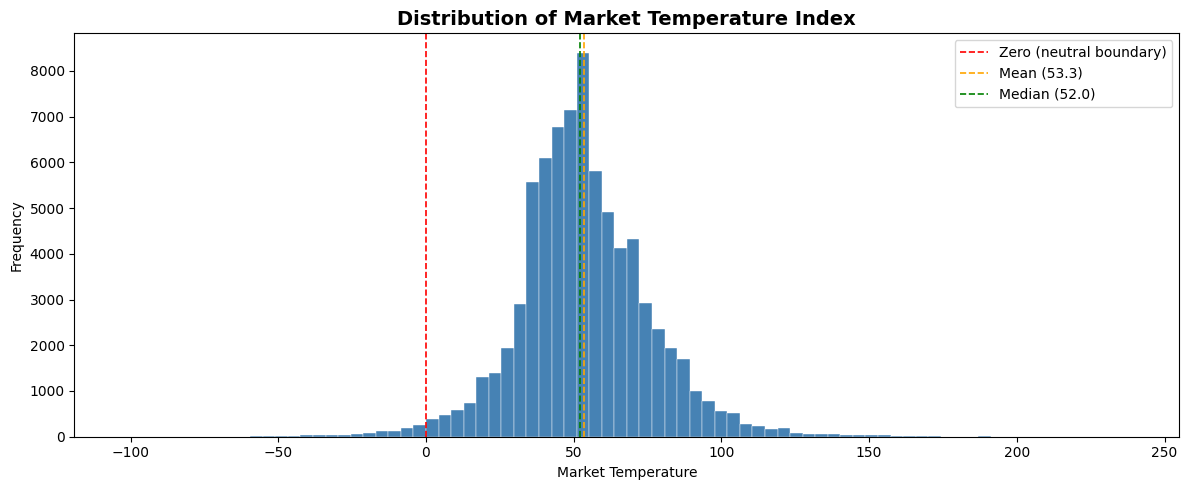

In [106]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_market_temp_updated['MarketTemperature'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero (neutral boundary)')
ax.axvline(df_market_temp_updated['MarketTemperature'].mean(), color='orange', linestyle='--', linewidth=1.2, label=f"Mean ({df_market_temp_updated['MarketTemperature'].mean():.1f})")
ax.axvline(df_market_temp_updated['MarketTemperature'].median(), color='green', linestyle='--', linewidth=1.2, label=f"Median ({df_market_temp_updated['MarketTemperature'].median():.1f})")

ax.set_title('Distribution of Market Temperature Index', fontsize=14, weight='bold')
ax.set_xlabel('Market Temperature')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

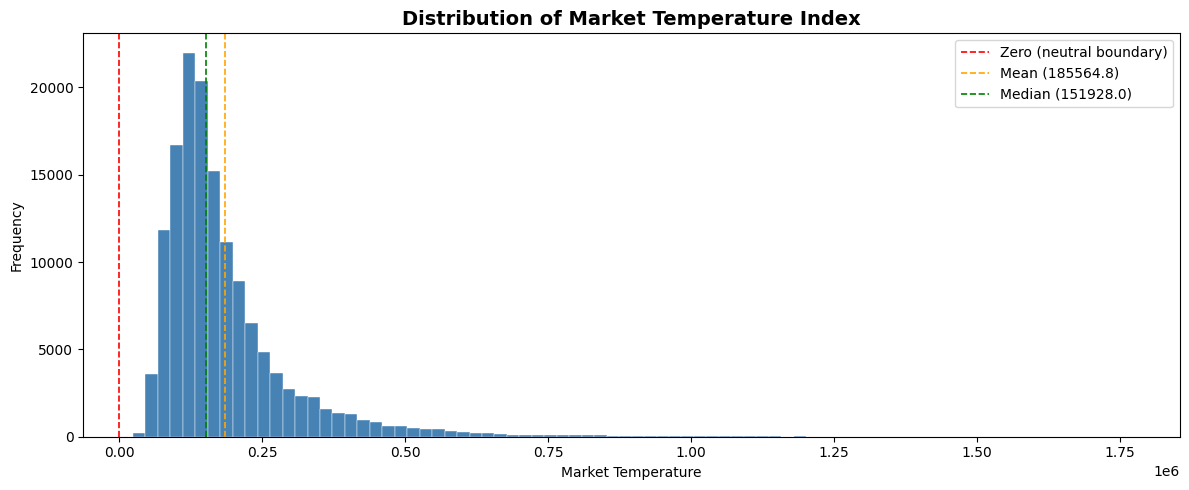

In [109]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_sale_price_updated['MedianSalePrice'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero (neutral boundary)')
ax.axvline(df_sale_price_updated['MedianSalePrice'].mean(), color='orange', linestyle='--', linewidth=1.2, label=f"Mean ({df_sale_price_updated['MedianSalePrice'].mean():.1f})")
ax.axvline(df_sale_price_updated['MedianSalePrice'].median(), color='green', linestyle='--', linewidth=1.2, label=f"Median ({df_sale_price_updated['MedianSalePrice'].median():.1f})")

ax.set_title('Distribution of Market Temperature Index', fontsize=14, weight='bold')
ax.set_xlabel('Market Temperature')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

# Focusing on 5 different US states , describing the time series patterns (visually and numerically)

# PLOTS

I choose the following regions because they are geographically spread across West, South, and Northeast, a mix of supply-constrained and high-growth markets, and different economic drivers (tech, Sun Belt growth, finance).

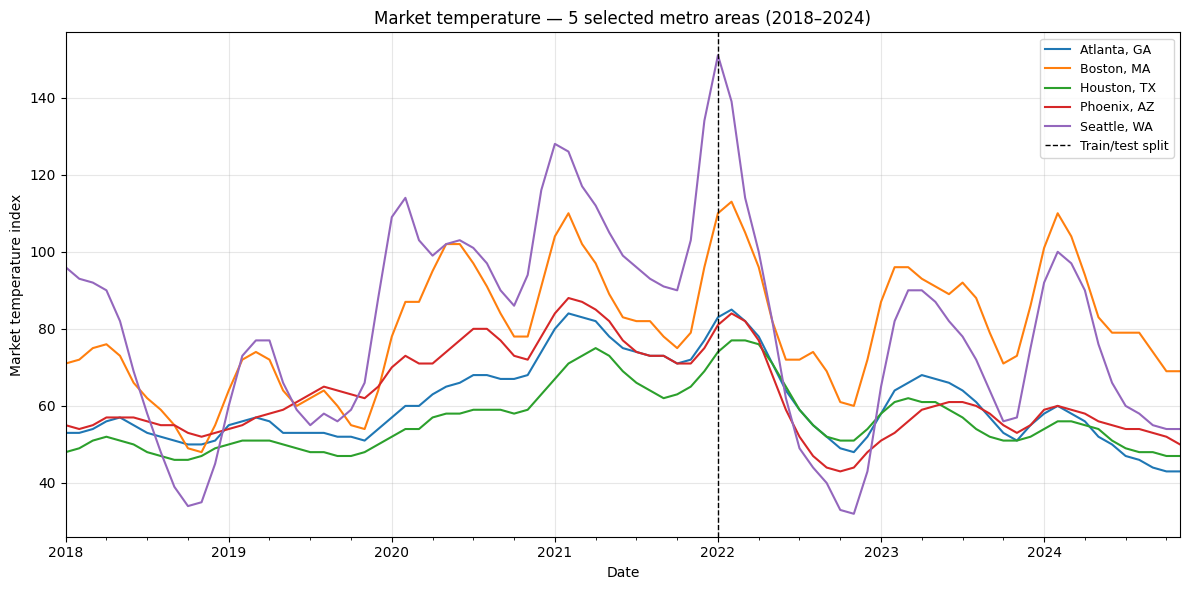

In [82]:
selected_regions = [
    "Houston, TX",
    "Phoenix, AZ",
    "Seattle, WA",
    "Atlanta, GA",
    "Boston, MA"
]

df_sample = df_market_temp_updated[
    df_market_temp_updated["RegionName"].isin(selected_regions)
]

fig, ax = plt.subplots(figsize=(12, 6))

df_sample.reset_index().pivot(
    index="Date",
    columns="RegionName",
    values="MarketTemperature"
).plot(ax=ax)

ax.axvline(
    pd.Timestamp("2022-01-01"),
    color="black", linestyle="--", linewidth=1, label="Train/test split"
)
ax.set_title("Market temperature — 5 selected metro areas (2018–2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Market temperature index")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

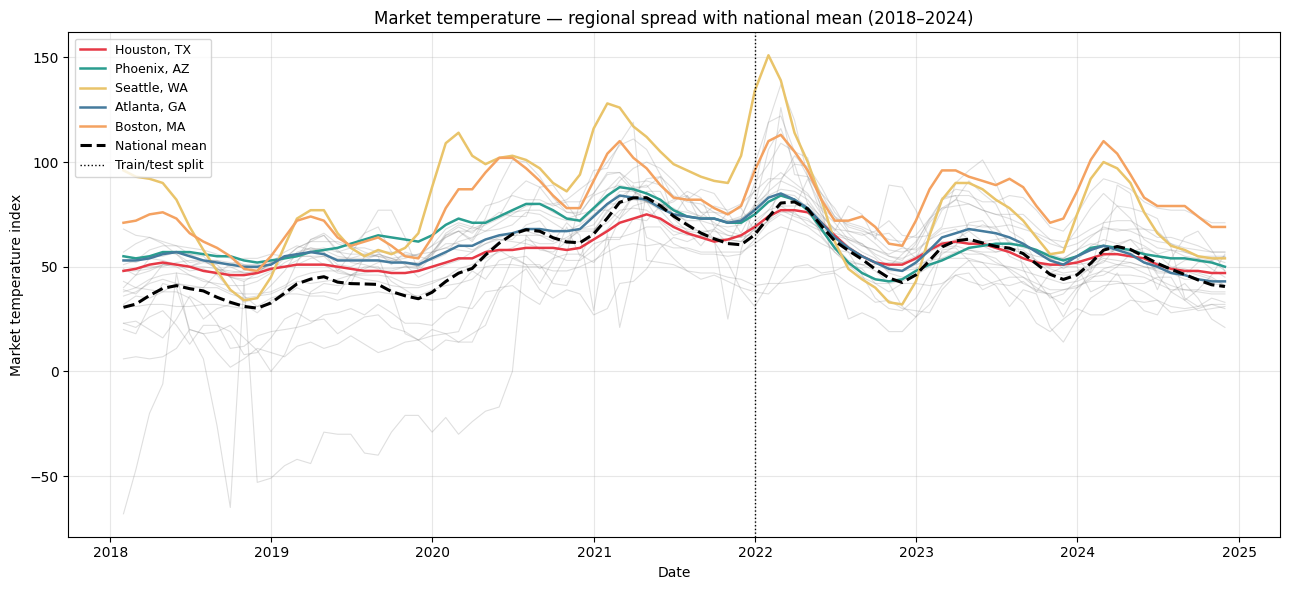

In [85]:
# pick a representative sample of regions for visibility
import numpy as np

rng = np.random.default_rng()
background_regions = rng.choice(
    df_market_temp_updated["RegionName"].unique(),
    size=20,
    replace=False
)

# pivot to wide format for easy plotting
df_wide = df_market_temp_updated.reset_index().pivot(
    index="Date",
    columns="RegionName",
    values="MarketTemperature"
)

# national mean across all metro areas
metro_only = df_market_temp_updated[
    df_market_temp_updated["RegionType"] == "msa"
]
national_mean = metro_only.groupby(level=0)["MarketTemperature"].mean()

fig, ax = plt.subplots(figsize=(13, 6))

# plot background regions in light grey — they show the spread
for region in background_regions:
    if region in df_wide.columns:
        ax.plot(
            df_wide.index,
            df_wide[region],
            color="grey",
            alpha=0.25,
            linewidth=0.8
        )

# overlay your 5 chosen cities in colour
colors = ["#E63946", "#2A9D8F", "#E9C46A", "#457B9D", "#F4A261"]
for city, color in zip(selected_regions, colors):
    if city in df_wide.columns:
        ax.plot(
            df_wide.index,
            df_wide[city],
            color=color,
            linewidth=1.8,
            label=city
        )

# national mean on top in bold
ax.plot(
    national_mean.index,
    national_mean,
    color="black",
    linewidth=2.2,
    linestyle="--",
    label="National mean"
)

ax.axvline(
    pd.Timestamp("2022-01-01"),
    color="black", linestyle=":", linewidth=1, label="Train/test split"
)

ax.set_title("Market temperature — regional spread with national mean (2018–2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Market temperature index")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Is there any associations with the market heat index (considering the common time window)?

# Choosing the appropriate model(s) to forecast the data for the specified period for each selected state/house type. Evaluate the model performance using different metrics. Visualise the results with appropriate graphs.